# Fase 5.1 — Feature Engineering

Construye las 5 variables acordadas con el equipo (ver `Respuesta_Marlon_Fase5.docx`,
sección 1.1) a partir del Parquet limpio de la Fase 3:

| Feature | Fuente | Propósito |
|---|---|---|
| `desviacion_paridad` | `close` del par de referencia (`USDCUSDT` o `BUSDUSDT_proxy` según `fuente_paridad`) | `ABS(close - 1.0)`, variable base de severidad |
| `severidad` | `desviacion_paridad` clasificada | Etiqueta de 3 niveles: normal / alerta / estrés |
| `volumen_relativo` | `volume` del par objetivo sobre su media móvil | Detecta picos de actividad |
| `spread_btc_usdc_usdt` | BTCUSDC vs BTCUSDT en el mismo instante | Señal de arbitraje / estrés de liquidez cruzada |
| `volatilidad_ventana` | desviación estándar móvil de los retornos (BTCUSDT, contexto de mercado) | Contexto de mercado, no solo el par objetivo |

Los umbrales de `severidad` se fijan con los **percentiles reales** de la distribución
histórica de `desviacion_paridad` (no números arbitrarios), como pide la sección 2.1
de la respuesta de Vilca.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (12, 4.5)

RUTA_DATOS = Path("../data/klines_clean")
RUTA_SALIDA = Path("../data/features.parquet")


## 1. Carga de datos

In [2]:
df = pd.read_parquet(RUTA_DATOS)
df = df.sort_values(["simbolo", "open_time_ts"]).reset_index(drop=True)

print(f"Total de filas: {len(df):,}")
print(f"Símbolos: {sorted(df['simbolo'].unique())}")

# Verificación pedida en la sección 2.2: confirmar que fuente_paridad existe
assert "fuente_paridad" in df.columns, "Falta la columna fuente_paridad"
print("\nValores de fuente_paridad:", df["fuente_paridad"].unique())


Total de filas: 48,271
Símbolos: ['BTCUSDC', 'BTCUSDT', 'BUSDUSDT', 'USDCUSDT']

Valores de fuente_paridad: <ArrowStringArray>
['BTCUSDC', 'BTCUSDT', 'BUSDUSDT_proxy', 'USDCUSDT']
Length: 4, dtype: str


## 2. Serie de paridad combinada (USDCUSDT + proxy BUSDUSDT)

Se concatenan las filas de `USDCUSDT` y `BUSDUSDT`. Como el proxy solo existe
en la ventana del hueco (donde USDCUSDT no tiene dato), la unión da una serie
continua de "precio de paridad" sin traslape, tal como ya se usó en el EDA
(Fase 4).

In [3]:
serie_paridad = df[df["simbolo"].isin(["USDCUSDT", "BUSDUSDT"])].copy()
serie_paridad = serie_paridad.sort_values("open_time_ts").reset_index(drop=True)

# Confirmar que no hay timestamps duplicados (no debe haber traslape USDCUSDT/proxy)
duplicados = serie_paridad["open_time_ts"].duplicated().sum()
print(f"Timestamps duplicados en la serie de paridad: {duplicados}")
assert duplicados == 0, "Hay traslape entre USDCUSDT y el proxy BUSDUSDT — revisar"

serie_paridad[["open_time_ts", "simbolo", "fuente_paridad", "close", "volume"]].head()


Timestamps duplicados en la serie de paridad: 0


,open_time_ts,simbolo,fuente_paridad,close,volume
0,2022-01-01 00:00:00,USDCUSDT,USDCUSDT,0.9999,2373259.0
1,2022-01-01 01:00:00,USDCUSDT,USDCUSDT,0.9999,4955001.0
2,2022-01-01 02:00:00,USDCUSDT,USDCUSDT,0.9999,1720917.0
3,2022-01-01 03:00:00,USDCUSDT,USDCUSDT,0.9999,3142564.0
4,2022-01-01 04:00:00,USDCUSDT,USDCUSDT,0.9999,957481.0


## 3. Feature 1 — `desviacion_paridad`

`desviacion_paridad = |close - 1.0|`, calculada sobre la serie de paridad combinada.

In [4]:
serie_paridad["desviacion_paridad"] = (serie_paridad["close"] - 1.0).abs()

serie_paridad[["open_time_ts", "fuente_paridad", "close", "desviacion_paridad"]].describe()


,open_time_ts,close,desviacion_paridad
count,17172,17172.000000,17172.000000
mean,2022-12-31 18:18:05.744235008,0.999893,0.000540
min,2022-01-01 00:00:00,0.912800,0.000000
25%,2022-06-28 20:45:00,0.999700,0.000100
50%,2022-12-29 14:30:00,0.999900,0.000300
75%,2023-07-06 02:15:00,1.000100,0.000500
max,2023-12-31 23:00:00,1.050000,0.087200
std,NaN,0.002423,0.002365


## 4. Umbrales de severidad (percentiles reales)

Según la sección 2.1: percentil 90 para el corte normal→alerta, y percentil 99
(o el mínimo observado durante los 3 eventos ancla) para el corte alerta→estrés.
Se documentan aquí los valores exactos usados, con el histograma como evidencia.

In [5]:
EVENTOS = {
    "Terra/UST (may-2022)": ("2022-05-07", "2022-05-17"),
    "FTX (nov-2022)": ("2022-11-05", "2022-11-15"),
    "SVB/USDC (mar-2023)": ("2023-03-08", "2023-03-18"),
}

p90 = serie_paridad["desviacion_paridad"].quantile(0.90)
p99 = serie_paridad["desviacion_paridad"].quantile(0.99)

# Desviación máxima alcanzada dentro de cada evento (para contrastar con el p99)
desviacion_minima_por_evento = {}
for nombre, (inicio, fin) in EVENTOS.items():
    ventana = serie_paridad[
        (serie_paridad["open_time_ts"] >= inicio) & (serie_paridad["open_time_ts"] <= fin)
    ]
    desviacion_minima_por_evento[nombre] = ventana["desviacion_paridad"].max()  # pico del evento

print(f"Percentil 90 de desviacion_paridad (histórico completo): {p90:.5f}")
print(f"Percentil 99 de desviacion_paridad (histórico completo): {p99:.5f}")
print("\nPico de desviación (máximo) alcanzado en cada evento ancla:")
for nombre, valor in desviacion_minima_por_evento.items():
    print(f"  {nombre}: {valor:.5f}")

# Umbral alerta->estrés: el más conservador entre el p99 histórico y el pico
# más pequeño de los tres eventos, para no dejar fuera al evento más leve (Terra/UST).
UMBRAL_ALERTA = p90
UMBRAL_ESTRES = min(p99, min(desviacion_minima_por_evento.values()))

print(f"\nUmbral normal->alerta (p90):  {UMBRAL_ALERTA:.5f}")
print(f"Umbral alerta->estrés (min(p99, pico mínimo de evento)): {UMBRAL_ESTRES:.5f}")


Percentil 90 de desviacion_paridad (histórico completo): 0.00110
Percentil 99 de desviacion_paridad (histórico completo): 0.00340

Pico de desviación (máximo) alcanzado en cada evento ancla:
  Terra/UST (may-2022): 0.05000
  FTX (nov-2022): 0.01290
  SVB/USDC (mar-2023): 0.08720

Umbral normal->alerta (p90):  0.00110
Umbral alerta->estrés (min(p99, pico mínimo de evento)): 0.00340


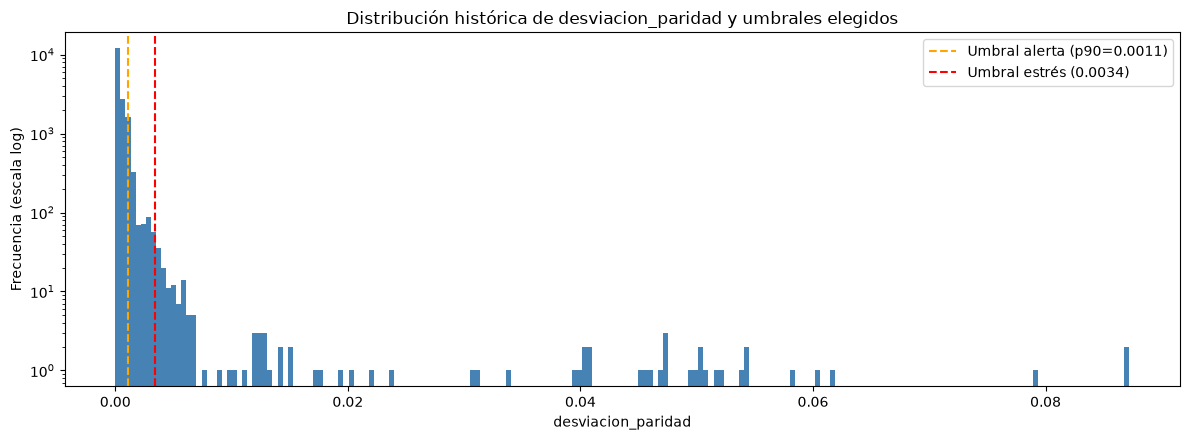

In [6]:
fig, ax = plt.subplots()
ax.hist(serie_paridad["desviacion_paridad"], bins=200, color="steelblue")
ax.axvline(UMBRAL_ALERTA, color="orange", linestyle="--", label=f"Umbral alerta (p90={UMBRAL_ALERTA:.4f})")
ax.axvline(UMBRAL_ESTRES, color="red", linestyle="--", label=f"Umbral estrés ({UMBRAL_ESTRES:.4f})")
ax.set_yscale("log")
ax.set_xlabel("desviacion_paridad")
ax.set_ylabel("Frecuencia (escala log)")
ax.set_title("Distribución histórica de desviacion_paridad y umbrales elegidos")
ax.legend()
plt.tight_layout()
plt.savefig("../informe/fig_umbrales_severidad.png", dpi=150)
plt.show()


## 5. Feature 2 — `severidad`

Clasificación de 3 niveles usando los umbrales definidos arriba.

In [7]:
def clasificar_severidad(desviacion):
    if desviacion >= UMBRAL_ESTRES:
        return "estres"
    elif desviacion >= UMBRAL_ALERTA:
        return "alerta"
    return "normal"

serie_paridad["severidad"] = serie_paridad["desviacion_paridad"].apply(clasificar_severidad)

conteo = serie_paridad["severidad"].value_counts()
print(conteo)
print(f"\nProporción:\n{(conteo / len(serie_paridad) * 100).round(2)}")


severidad
normal    15412
alerta     1587
estres      173
Name: count, dtype: int64

Proporción:
severidad
normal    89.75
alerta     9.24
estres     1.01
Name: count, dtype: float64


## 6. Feature 3 — `volumen_relativo`

`volume` del par de paridad sobre su media móvil de 24 horas (ventana de 1 día,
ya que los datos son horarios).

In [8]:
VENTANA_VOLUMEN = 24  # horas

serie_paridad["volumen_media_movil"] = (
    serie_paridad["volume"].rolling(window=VENTANA_VOLUMEN, min_periods=1).mean()
)
serie_paridad["volumen_relativo"] = serie_paridad["volume"] / serie_paridad["volumen_media_movil"]

serie_paridad[["open_time_ts", "volume", "volumen_media_movil", "volumen_relativo"]].describe()


,open_time_ts,volume,volumen_media_movil,volumen_relativo
count,17172,1.717200e+04,1.717200e+04,17172.000000
mean,2022-12-31 18:18:05.744235008,1.618647e+07,1.618065e+07,1.024660
min,2022-01-01 00:00:00,0.000000e+00,1.351881e+06,0.000000
25%,2022-06-28 20:45:00,4.792343e+06,7.110482e+06,0.515628
50%,2022-12-29 14:30:00,9.626426e+06,1.145599e+07,0.809004
75%,2023-07-06 02:15:00,1.945082e+07,1.997612e+07,1.270129
max,2023-12-31 23:00:00,7.779600e+08,2.015949e+08,11.140762
std,NaN,2.331997e+07,1.624109e+07,0.808727


## 7. Feature 4 — `spread_btc_usdc_usdt`

Diferencia relativa entre el precio de BTC cotizado en USDC y en USDT, en el
mismo instante. Señal de arbitraje / estrés de liquidez cruzada: si USDC pierde
confianza, el precio de BTCUSDC se desvía del de BTCUSDT.

In [9]:
btc_usdc = df[df["simbolo"] == "BTCUSDC"][["open_time_ts", "close"]].rename(columns={"close": "close_btcusdc"})
btc_usdt = df[df["simbolo"] == "BTCUSDT"][["open_time_ts", "close"]].rename(columns={"close": "close_btcusdt"})

spread_df = pd.merge(btc_usdc, btc_usdt, on="open_time_ts", how="inner")
spread_df["spread_btc_usdc_usdt"] = (
    (spread_df["close_btcusdc"] - spread_df["close_btcusdt"]) / spread_df["close_btcusdt"]
)

print(f"Filas con spread calculado: {len(spread_df):,} de {len(btc_usdc):,} timestamps de BTCUSDC")
spread_df[["open_time_ts", "close_btcusdc", "close_btcusdt", "spread_btc_usdc_usdt"]].describe()


Filas con spread calculado: 13,580 de 13,580 timestamps de BTCUSDC


,open_time_ts,close_btcusdc,close_btcusdt,spread_btc_usdc_usdt
count,13580,13580.00000,13580.000000,13580.000000
mean,2023-01-04 09:35:08.836524288,31090.68192,31086.673383,0.000118
min,2022-01-01 00:00:00,17781.11000,17809.000000,-0.041116
25%,2022-05-22 10:45:00,26117.93750,26124.697500,-0.000202
50%,2023-03-24 00:30:00,29286.14000,29292.515000,0.000114
75%,2023-08-12 12:15:00,37969.33000,37958.277500,0.000375
max,2023-12-31 23:00:00,47998.44000,47970.990000,0.064271
std,NaN,7617.49322,7614.416247,0.002079


## 8. Feature 5 — `volatilidad_ventana`

Desviación estándar móvil (24h) de los retornos porcentuales de BTCUSDT, como
contexto general del mercado (no solo el par objetivo), tal como pide la
sección 1.1.

In [10]:
VENTANA_VOLATILIDAD = 24  # horas

btc_mercado = df[df["simbolo"] == "BTCUSDT"][["open_time_ts", "close"]].sort_values("open_time_ts").copy()
btc_mercado["retorno"] = btc_mercado["close"].pct_change()
btc_mercado["volatilidad_ventana"] = (
    btc_mercado["retorno"].rolling(window=VENTANA_VOLATILIDAD, min_periods=2).std()
)

btc_mercado[["open_time_ts", "close", "retorno", "volatilidad_ventana"]].describe()


,open_time_ts,close,retorno,volatilidad_ventana
count,17519,17519.000000,17518.000000,17517.000000
mean,2022-12-31 23:23:12.819225088,28514.894989,0.000011,0.004909
min,2022-01-01 00:00:00,15649.520000,-0.069890,0.000455
25%,2022-07-02 11:30:00,21433.885000,-0.001998,0.002868
50%,2022-12-31 23:00:00,27259.690000,0.000039,0.004332
75%,2023-07-02 11:30:00,34980.020000,0.002055,0.006090
max,2023-12-31 23:00:00,47970.990000,0.064872,0.027461
std,NaN,8325.920937,0.005790,0.003064


## 9. Ensamblado del dataset de features

Se combinan las 5 features en un solo DataFrame, indexado por `open_time_ts`,
conservando `fuente_paridad` para poder distinguir después, en la Fase 5.3,
entre desempeño sobre dato real y desempeño sobre el proxy (sección 2.2).

In [11]:
features = serie_paridad[[
    "open_time_ts", "fuente_paridad", "close", "volume",
    "desviacion_paridad", "severidad", "volumen_relativo",
]].copy()

features = features.merge(
    spread_df[["open_time_ts", "spread_btc_usdc_usdt"]], on="open_time_ts", how="left"
)
features = features.merge(
    btc_mercado[["open_time_ts", "volatilidad_ventana"]], on="open_time_ts", how="left"
)

features = features.sort_values("open_time_ts").reset_index(drop=True)

print(f"Dataset de features: {len(features):,} filas, {features.shape[1]} columnas")
print(f"Nulos por columna:\n{features.isna().sum()}")
features.head()


Dataset de features: 17,172 filas, 9 columnas
Nulos por columna:
open_time_ts               0
fuente_paridad             0
close                      0
volume                     0
desviacion_paridad         0
severidad                  0
volumen_relativo           0
spread_btc_usdc_usdt    3664
volatilidad_ventana        2
dtype: int64


,open_time_ts,fuente_paridad,close,volume,desviacion_paridad,severidad,volumen_relativo,spread_btc_usdc_usdt,volatilidad_ventana
0,2022-01-01 00:00:00,USDCUSDT,0.9999,2373259.0,0.0001,normal,1.000000,-0.000065,NaN
1,2022-01-01 01:00:00,USDCUSDT,0.9999,4955001.0,0.0001,normal,1.352299,-0.000035,NaN
2,2022-01-01 02:00:00,USDCUSDT,0.9999,1720917.0,0.0001,normal,0.570522,0.000099,0.001341
3,2022-01-01 03:00:00,USDCUSDT,0.9999,3142564.0,0.0001,normal,1.031047,-0.000035,0.001338
4,2022-01-01 04:00:00,USDCUSDT,0.9999,957481.0,0.0001,normal,0.364083,0.000140,0.001981


In [12]:
features.to_parquet(RUTA_SALIDA, index=False)
print(f"Guardado en: {RUTA_SALIDA.resolve()}")


Guardado en: /home/marlon/stablecoin-depeg-detection/data/features.parquet


## 10. Resumen para el informe

- Umbrales de severidad: **normal→alerta = p90 de la distribución histórica**
  (ver celda de la sección 4); **alerta→estrés = mínimo entre el p99 histórico
  y el pico más bajo de los tres eventos ancla** (para no excluir el evento más leve).
- Figura `informe/fig_umbrales_severidad.png` con el histograma y los umbrales marcados.
- Dataset de features guardado en `data/features.parquet`, con la columna `fuente_paridad`
  conservada para el análisis de la Fase 5.3 (real vs. proxy).
- Siguiente paso: `05_modelo_baseline.ipynb` — clasificador de 3 niveles con las
  3 combinaciones de validación cruzada (Terra+SVB→FTX, Terra+FTX→SVB, FTX+SVB→Terra).